In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_theme('paper')

RANDOM_STATE = 55

In [2]:
df = pd.read_csv('dataset/heart.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
cat_variables = ['Sex',
                 'ChestPainType',
                 'RestingECG',
                 'ExerciseAngina',
                 'ST_Slope'
                 ]

In [5]:
df = pd.get_dummies(df, prefix=cat_variables, columns=cat_variables)
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [6]:
features = [x for x in df.columns if x not in 'HeartDisease']
print(len(features))

20


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    df[features], df['HeartDisease'], train_size=.8, random_state=RANDOM_STATE)

print(X_train.shape)
print(X_val.shape)
print(np.mean(y_train))

(734, 20)
(184, 20)
0.5517711171662125


In [8]:
min_samples_split_list = [2, 10, 30, 50, 100, 200, 300, 700]
max_depth_list = [1, 2, 3, 4, 8, 16, 32, 64, None]

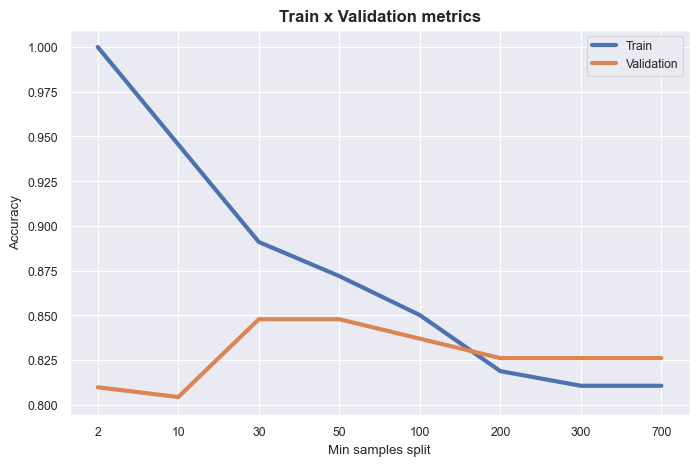

In [9]:
accuracy_list_train = []
accuracy_list_val = []

for min_samples_split in min_samples_split_list:
    model = DecisionTreeClassifier(
        min_samples_split=min_samples_split, random_state=RANDOM_STATE).fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    accuracy_list_train.append(accuracy_score(pred_train, y_train))
    accuracy_list_val.append(accuracy_score(pred_val, y_val))


plt.figure(figsize=(8, 5))
ax = sns.lineplot(accuracy_list_train, linewidth=3, label='Train')
sns.lineplot(accuracy_list_val, linewidth=3, label='Validation', ax=ax)
ax.set_title('Train x Validation metrics', fontsize=12, fontweight="bold")
ax.set_xlabel('Min samples split')
ax.set_ylabel('Accuracy')
ax.set_xticks(range(len(min_samples_split_list)), min_samples_split_list)  # type: ignore
plt.show()

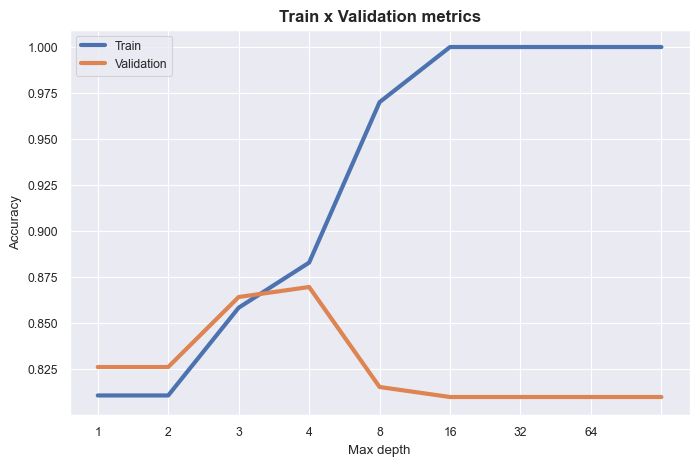

In [10]:
accuracy_list_train = []
accuracy_list_val = []

for max_depth in max_depth_list:
    model = DecisionTreeClassifier(
        max_depth=max_depth, random_state=RANDOM_STATE).fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    accuracy_list_train.append(accuracy_score(pred_train, y_train))
    accuracy_list_val.append(accuracy_score(pred_val, y_val))


plt.figure(figsize=(8, 5))
ax = sns.lineplot(accuracy_list_train, linewidth=3, label='Train')
sns.lineplot(accuracy_list_val, linewidth=3, label='Validation', ax=ax)
ax.set_title('Train x Validation metrics', fontsize=12, fontweight="bold")
ax.set_xlabel('Max depth')
ax.set_ylabel('Accuracy')
ax.set_xticks(range(len(max_depth_list)), max_depth_list)  # type: ignore
plt.show()

In [11]:
decision_tree_model = DecisionTreeClassifier(min_samples_split=50,
                                             max_depth=4,
                                             random_state=RANDOM_STATE).fit(X_train, y_train)

print(
    f"Metrics train:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_train), y_train):.4f}")
print(
    f"Metrics validation:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_val), y_val):.4f}")

Metrics train:
	Accuracy score: 0.8665
Metrics validation:
	Accuracy score: 0.8696


In [12]:
min_samples_split_list = [2, 10, 30, 50, 100, 200, 300, 700]
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10, 50, 100, 500]

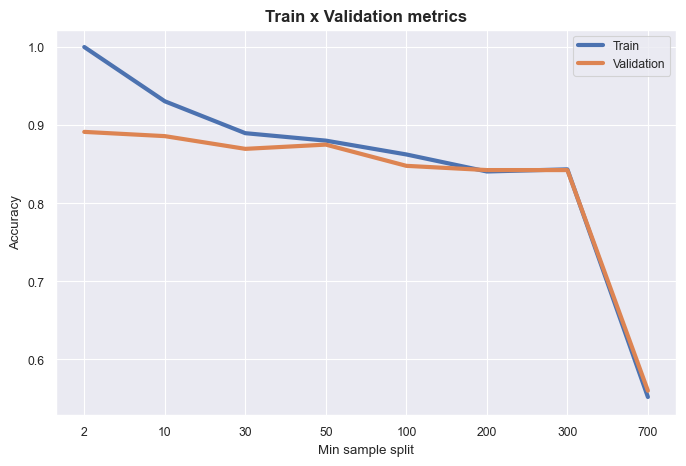

In [13]:
accuracy_list_train = []
accuracy_list_val = []

for min_samples_split in min_samples_split_list:
    model = RandomForestClassifier(
        min_samples_split=min_samples_split,
        random_state=RANDOM_STATE).fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    accuracy_list_train.append(accuracy_score(pred_train, y_train))
    accuracy_list_val.append(accuracy_score(pred_val, y_val))


plt.figure(figsize=(8, 5))
ax = sns.lineplot(accuracy_list_train, linewidth=3, label='Train')
sns.lineplot(accuracy_list_val, linewidth=3, label='Validation', ax=ax)
ax.set_title('Train x Validation metrics', fontsize=12, fontweight="bold")
ax.set_xlabel('Min sample split')
ax.set_ylabel('Accuracy')
ax.set_xticks(range(len(min_samples_split_list)), min_samples_split_list)  # type: ignore
plt.show()

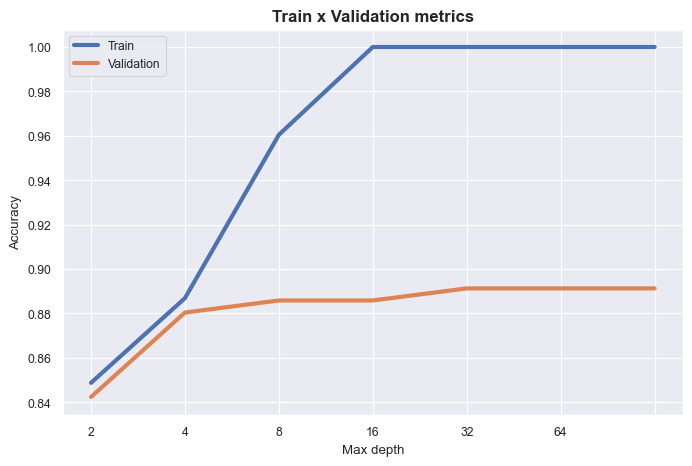

In [14]:
accuracy_list_train = []
accuracy_list_val = []

for max_depth in max_depth_list:
    model = RandomForestClassifier(
        max_depth=max_depth,
        random_state=RANDOM_STATE).fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    accuracy_list_train.append(accuracy_score(pred_train, y_train))
    accuracy_list_val.append(accuracy_score(pred_val, y_val))


plt.figure(figsize=(8, 5))
ax = sns.lineplot(accuracy_list_train, linewidth=3, label='Train')
sns.lineplot(accuracy_list_val, linewidth=3, label='Validation', ax=ax)
ax.set_title('Train x Validation metrics', fontsize=12, fontweight="bold")
ax.set_xlabel('Max depth')
ax.set_ylabel('Accuracy')
ax.set_xticks(range(len(max_depth_list)), max_depth_list)  # type: ignore
plt.show()

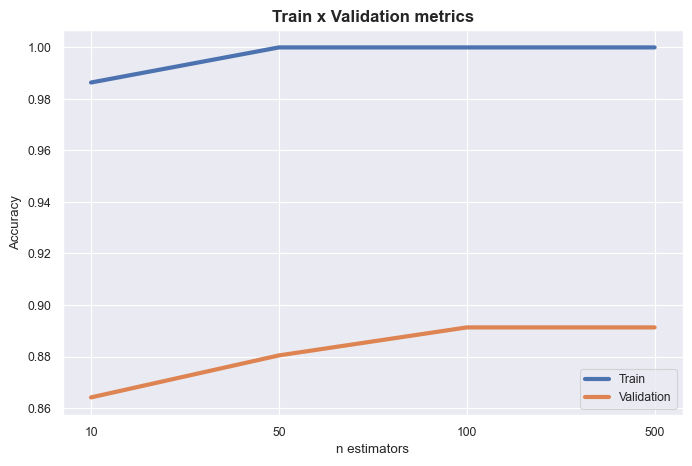

In [15]:
accuracy_list_train = []
accuracy_list_val = []

for n_estimators in n_estimators_list:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE).fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    accuracy_list_train.append(accuracy_score(pred_train, y_train))
    accuracy_list_val.append(accuracy_score(pred_val, y_val))


plt.figure(figsize=(8, 5))
ax = sns.lineplot(accuracy_list_train, linewidth=3, label='Train')
sns.lineplot(accuracy_list_val, linewidth=3, label='Validation', ax=ax)
ax.set_title('Train x Validation metrics', fontsize=12, fontweight="bold")
ax.set_xlabel('n estimators')
ax.set_ylabel('Accuracy')
ax.set_xticks(range(len(n_estimators_list)), n_estimators_list)  # type: ignore
plt.show()

In [16]:
random_forest_model = RandomForestClassifier(n_estimators=100,
                                             max_depth=16,
                                             min_samples_split=10).fit(X_train, y_train)

print(f"Metrics train:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_train), y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_val), y_val):.4f}")

Metrics train:
	Accuracy score: 0.9373
Metrics test:
	Accuracy score: 0.8913
